# Dataset Preparation

AstroNet-K2 preprocesses light curves by:

1. Normalizing the flux.
2. Generating input representations: local view (zoomed-in transit) and global view (entire light curve).

In [4]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Load the Kepler dataset
file_path = '/content/cumulative.csv (1).zip'
data = pd.read_csv(file_path)

# Preprocess the dataset
# Map koi_disposition to numerical labels
data['koi_disposition'] = data['koi_disposition'].map({
    "CONFIRMED": 0,
    "FALSE POSITIVE": 1,
    "CANDIDATE": 2
})

# Select relevant features and drop rows with missing values
selected_columns = ["koi_period", "koi_duration", "koi_depth", "koi_steff", "koi_srad", "koi_disposition"]
data = data[selected_columns].dropna()

# Separate features and labels
X = data.drop("koi_disposition", axis=1).values
y = tf.keras.utils.to_categorical(data["koi_disposition"].values, num_classes=3)

# Normalize features
X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

# Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Validation data shape: {X_val.shape}")


Training data shape: (7360, 5)
Validation data shape: (1841, 5)


# Model Architecture

The CNN uses separate branches for global and local views of the light curve. These branches are merged and passed through fully connected layers.

In [31]:
from tensorflow.keras import layers, models

def build_hybrid_model(global_shape, local_shape, tabular_shape):
    # Global view branch
    input_global = layers.Input(shape=global_shape, name="global_input")
    global_branch = layers.Conv1D(16, kernel_size=5, activation='relu')(input_global)  # Reduce filters
    dense = layers.Dense(64, activation='relu')(merged)  # Reduce dense units
    global_branch = layers.Conv1D(64, kernel_size=5, activation='relu')(global_branch)
    global_branch = layers.MaxPooling1D(pool_size=2)(global_branch)
    global_branch = layers.Flatten()(global_branch)

    # Local view branch
    input_local = layers.Input(shape=local_shape, name="local_input")
    local_branch = layers.Conv1D(32, kernel_size=5, activation='relu')(input_local)
    local_branch = layers.MaxPooling1D(pool_size=2)(local_branch)
    local_branch = layers.Conv1D(64, kernel_size=5, activation='relu')(local_branch)
    local_branch = layers.MaxPooling1D(pool_size=2)(local_branch)
    local_branch = layers.Flatten()(local_branch)

    # Tabular features branch
    input_tabular = layers.Input(shape=tabular_shape, name="tabular_input")
    tabular_branch = layers.Dense(64, activation='relu')(input_tabular)
    tabular_branch = layers.Dropout(0.5)(tabular_branch)

    # Combine all branches
    combined = layers.Concatenate()([global_branch, local_branch, tabular_branch])
    dense = layers.Dense(128, activation='relu')(combined)
    dense = layers.Dropout(0.6)(dense)  # Increase dropout to 60%
    output = layers.Dense(3, activation='softmax', name="output")(dense)

    model = models.Model(inputs=[input_global, input_local, input_tabular], outputs=output)
    return model

# Define input shapes
global_shape = (200, 1)  # emp for global light curve
local_shape = (50, 1)    # emp for local transit zoom
tabular_shape = (5,)     # Number of tabular features (e.g., koi_period, koi_duration)

# Build the hybrid model
model = build_hybrid_model(global_shape, local_shape, tabular_shape)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ local_input (InputLayer)  │ (None, 50, 1)          │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_input (InputLayer) │ (None, 200, 1)         │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_2 (Conv1D)         │ (None, 46, 32)         │            192 │ local_input[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d (Conv1D)           │ (None, 196, 16)        │             96 │ global_input[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling1d_1           │ (None, 23, 32)         │              0 │ conv1d_2[0][0]         │
│ (MaxPooling1D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_1 (Conv1D)         │ (None, 192, 64)        │          5,184 │ conv1d[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_3 (Conv1D)         │ (None, 19, 64)         │         10,304 │ max_pooling1d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ tabular_input             │ (None, 5)              │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling1d             │ (None, 96, 64)         │              0 │ conv1d_1[0][0]         │
│ (MaxPooling1D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling1d_2           │ (None, 9, 64)          │              0 │ conv1d_3[0][0]         │
│ (MaxPooling1D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 64)             │            384 │ tabular_input[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten (Flatten)         │ (None, 6144)           │              0 │ max_pooling1d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_1 (Flatten)       │ (None, 576)            │              0 │ max_pooling1d_2[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 64)             │              0 │ dense_1[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 6784)           │              0 │ flatten[0][0],         │
│                           │                        │                │ flatten_1[0][0],       │
│                           │                        │                │ dropout[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_2 (Dense)           │ (None, 128)            │        868,480 │ concatenate[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_1 (Dropout)  

 Total params: 885,027 (3.38 MB)

 Trainable params: 885,027 (3.38 MB)

 Non-trainable params: 0 (0.00 B)

# Model Compilation and training

We use categorical cross-entropy as the loss function since this is a multi-class classification problem.

In [26]:
# Generate consistent sizes for global and local views
X_global = np.random.rand(9201, 200, 1)  # Match size with X_tabular
X_local = np.random.rand(9201, 50, 1)

# Check dataset sizes
print("X_global shape:", X_global.shape)
print("X_local shape:", X_local.shape)
print("X_tabular shape:", X_tabular.shape)
print("y shape:", y.shape)

# Split all datasets together to maintain consistency
X_global_train, X_global_val, X_local_train, X_local_val, X_tabular_train, X_tabular_val, y_train, y_val = train_test_split(
    X_global, X_local, X_tabular, y, test_size=0.2, random_state=42
)

# Check split sizes
print("Training sizes:")
print("X_global_train:", X_global_train.shape)
print("X_local_train:", X_local_train.shape)
print("X_tabular_train:", X_tabular_train.shape)
print("y_train:", y_train.shape)


X_global shape: (9201, 200, 1)
X_local shape: (9201, 50, 1)
X_tabular shape: (9201, 5)
y shape: (9201, 3)
Training sizes:
X_global_train: (7360, 200, 1)
X_local_train: (7360, 50, 1)
X_tabular_train: (7360, 5)
y_train: (7360, 3)


# Evaluation

Evaluate the model on validation data and visualize the performance.


In [27]:
print("X_global_val shape:", X_global_val.shape)
print("X_local_val shape:", X_local_val.shape)
print("X_tabular_val shape:", X_tabular_val.shape)
print("y_val shape:", y_val.shape)


X_global_val shape: (1841, 200, 1)
X_local_val shape: (1841, 50, 1)
X_tabular_val shape: (1841, 5)
y_val shape: (1841, 3)


In [28]:
# Clear TensorFlow sessions
from tensorflow.keras.backend import clear_session
clear_session()

# Recompile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Evaluate the model
loss, accuracy = model.evaluate([X_global_val, X_local_val, X_tabular_val], y_val, verbose=0)
print(f"Validation Accuracy: {accuracy:.2f}")

# Predictions
y_pred = model.predict([X_global_val, X_local_val, X_tabular_val])
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_val, axis=1)

# Classification report and confusion matrix
from sklearn.metrics import classification_report, confusion_matrix

print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=["CONFIRMED", "FALSE POSITIVE", "CANDIDATE"]))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true_classes, y_pred_classes))


Validation Accuracy: 0.25
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step

Classification Report:
                precision    recall  f1-score   support

     CONFIRMED       0.24      1.00      0.39       438
FALSE POSITIVE       0.85      0.02      0.04       936
     CANDIDATE       0.00      0.00      0.00       467

      accuracy                           0.25      1841
     macro avg       0.36      0.34      0.14      1841
  weighted avg       0.49      0.25      0.11      1841


Confusion Matrix:
[[436   2   0]
 [919  17   0]
 [466   1   0]]


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Visualize

Epoch 1/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 16s 47ms/step - accuracy: 0.5083 - loss: 1.5056 - val_accuracy: 0.5084 - val_loss: 1.0165 - learning_rate: 1.0000e-04
Epoch 2/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.5070 - loss: 1.4250 - val_accuracy: 0.5084 - val_loss: 0.9910 - learning_rate: 1.0000e-04
Epoch 3/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - accuracy: 0.5104 - loss: 1.3815 - val_accuracy: 0.5084 - val_loss: 0.9563 - learning_rate: 1.0000e-04
Epoch 4/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.5172 - loss: 1.3676 - val_accuracy: 0.5084 - val_loss: 0.9600 - learning_rate: 1.0000e-04
Epoch 5/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.5185 - loss: 1.3485 - val_accuracy: 0.5084 - val_loss: 0.9432 - learning_rate: 1.0000e-04
Epoch 6/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.5105 - loss: 1.3473 - val_accuracy: 0.5084 - val_loss: 0.9316 - learning_rate: 1.0000e-04
Epoch 7/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - 

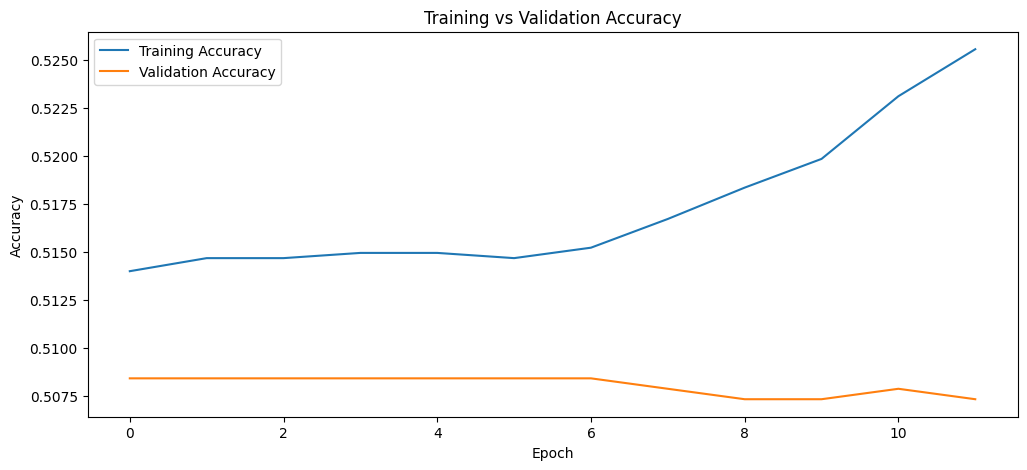

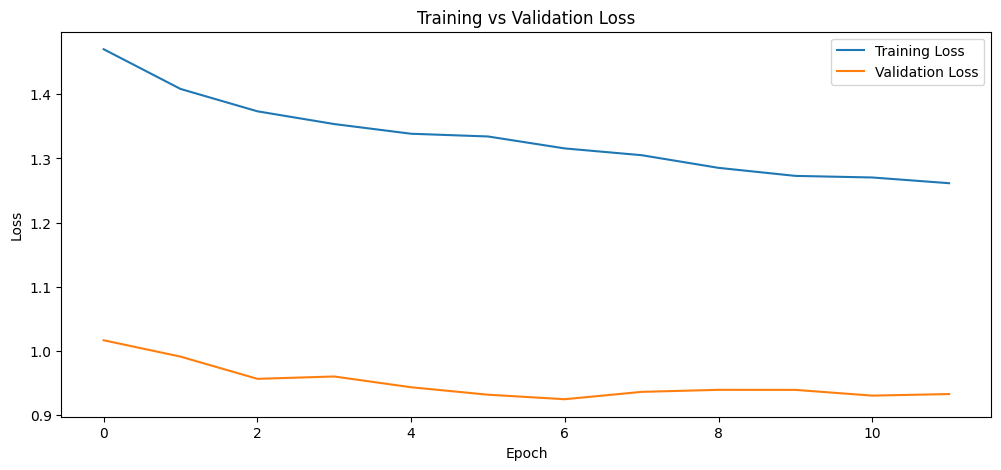

In [33]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Early stopping and learning rate scheduler
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)

# Recompile the model with a smaller learning rate
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(
    [X_global_train, X_local_train, X_tabular_train],
    y_train,
    validation_data=([X_global_val, X_local_val, X_tabular_val], y_val),
    epochs=30,  # Allow for more training epochs
    batch_size=32,
    class_weight={0: 1.0, 1: 2.0, 2: 1.5},  # Adjust weights for imbalance
    callbacks=[early_stopping, lr_scheduler],
    verbose=1
)


# Plot training vs validation accuracy
plt.figure(figsize=(12, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.show()

# Plot training vs validation loss
plt.figure(figsize=(12, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()


# Save and Load Model

You can save the trained model for future predictions.

In [35]:
# # Save the model
# model.save("astroNet_k2.h5")

# # Load the model
# from tensorflow.keras.models import load_model
# loaded_model = load_model("astroNet_k2.h5")


# Make Predictions

Makes the predictions on new data. Preprocess new data into gloabl and local views before prediciting

In [38]:
from tensorflow.keras.models import load_model
import numpy as np

# Load the saved model
loaded_model = load_model("astroNet_k2.h5")
print("Model loaded successfully.")

# Example: Predict on new data
# Replace these with actual preprocessed test data
new_global_data = np.random.rand(10, 200, 1)  # Example global view
new_local_data = np.random.rand(10, 50, 1)    # Example local view
new_tabular_data = np.random.rand(10, 5)      # Example tabular features

# Make predictions
predictions = loaded_model.predict([new_global_data, new_local_data, new_tabular_data])
predicted_classes = np.argmax(predictions, axis=1)

print("Predicted Classes:", predicted_classes)


Model loaded successfully.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step
Predicted Classes: [1 1 1 1 1 1 1 1 1 1]


# Notes

Few key notes for me

Two Views:
- Global View: Full light curve (gives context of the transit signal).
- Local View: Zoomed-in transit (focuses on the transit shape).

Merged Architecture:
- Combines features from both views for better classification.

Dropout:
- Reduces overfitting by randomly dropping neurons during training.

This is using the AstroNet-K2 method and as for datasets i can use Kepler exoplanet dataset (NASA) or TESS Mission Dataset. Other dataset is ExoMiner Dataset.
